In [44]:
import pandas as pd
import os
from pathlib import Path

In [45]:
def load_data(path: str) -> pd.DataFrame:
    """loads data from a csv file and returns a pandas DataFrame"""
    df = pd.read_csv(path)
    return df


def load_customers() -> pd.DataFrame:
    """loads customer data from the subject folder and returns a pandas DataFrame"""
    dfs = []
    base_path = Path.cwd()
    data_path = (base_path / "../subject/customer").resolve()

    if not data_path.exists():
        print(f"Directory not found: {data_path}")
        return

    for file in data_path.glob("*.csv"):
        dfs.append(pd.read_csv(file))
        
    contacts = pd.concat(dfs)
    contacts['event_time'] = pd.to_datetime(contacts['event_time'])
    return contacts


def load_items():
    """loads item data from the subject folder and returns a pandas DataFrame"""
    df = load_data("../subject/item/item.csv")
    return df


def merge_data(items, customers) -> pd.DataFrame:
    """merges the customer and item dataframes on the product_id column and returns a new DataFrame"""
    df = pd.merge(customers, items, on="product_id")
    return df


def remove_doubles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Removes rows where the same product, event, and user session 
    occur within 1 second of each other.
    """
    df = df.copy()
    df['event_time'] = pd.to_datetime(df['event_time'])
    
    sort_cols = ['user_id', 'product_id', 'event_type', 'event_time']
    df = df.sort_values(by=sort_cols)
    
    group_cols = ['user_id', 'product_id', 'event_type']
    time_diff = df.groupby(group_cols)['event_time'].diff()
    
    mask = (time_diff > pd.Timedelta(seconds=1)) | (time_diff.isna())
    
    return df[mask].reset_index(drop=True)

In [46]:
customers = load_customers()
customers = remove_doubles(customers)
items = load_items()
customers = merge_data(items, customers)

In [47]:
frequency = customers[customers['event_type'] == "purchase"]
frequency = frequency.groupby("user_id").size().reset_index(name="purchase_count")
frequency.head()

,user_id,purchase_count
0,9794320,12
1,10079204,5
2,10280338,41
3,12055855,10
4,12936739,5


In [48]:
monetary = customers[customers['event_type'] == "purchase"]
monetary = monetary.groupby("user_id")["price"].sum().reset_index(name="total_spent")
monetary.head()

,user_id,total_spent
0,9794320,38.04
1,10079204,65.18
2,10280338,186.70
3,12055855,42.05
4,12936739,86.75


In [49]:
data = pd.merge(frequency, monetary, on="user_id")
data.head()


,user_id,purchase_count,total_spent
0,9794320,12,38.04
1,10079204,5,65.18
2,10280338,41,186.70
3,12055855,10,42.05
4,12936739,5,86.75


In [50]:
last_purchase_date = customers[customers['event_type'] == "purchase"].groupby("user_id")["event_time"].max().reset_index(name="last_purchase_date")
latest_date = last_purchase_date['last_purchase_date'].max()
data['days_since_last'] = (latest_date - last_purchase_date['last_purchase_date']).dt.days
data.head()

,user_id,purchase_count,total_spent,days_since_last
0,9794320,12,38.04,67
1,10079204,5,65.18,86
2,10280338,41,186.70,19
3,12055855,10,42.05,42
4,12936739,5,86.75,14


In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.drop(columns=["user_id"]))
data_scaled = pd.DataFrame(data_scaled, columns=data.columns[1:])
data_scaled.head()

,purchase_count,total_spent,days_since_last
0,-0.382834,-0.491490,0.314407
1,-0.554694,-0.351872,0.847968
2,0.329155,0.273274,-1.033535
3,-0.431937,-0.470861,-0.387646
4,-0.554694,-0.240907,-1.173946


In [52]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
data_scaled['cluster'] = kmeans.fit_predict(data_scaled)
data['cluster'] = data_scaled['cluster']
data_scaled.head()
data_scaled.rename(columns={"purchase_count": "Frequency", "total_spent": "Monetary", "days_since_last": "Recency"}, inplace=True)
data_scaled.head()

,Frequency,Monetary,Recency,cluster
0,-0.382834,-0.491490,0.314407,1
1,-0.554694,-0.351872,0.847968,0
2,0.329155,0.273274,-1.033535,3
3,-0.431937,-0.470861,-0.387646,1
4,-0.554694,-0.240907,-1.173946,3


In [56]:
data.rename(columns={"purchase_count": "Frequency", "total_spent": "Monetary", "days_since_last": "Recency"}, inplace=True)
data.head()

,user_id,Frequency,Monetary,Recency,cluster
0,9794320,12,38.04,67,1
1,10079204,5,65.18,86,0
2,10280338,41,186.70,19,3
3,12055855,10,42.05,42,1
4,12936739,5,86.75,14,3


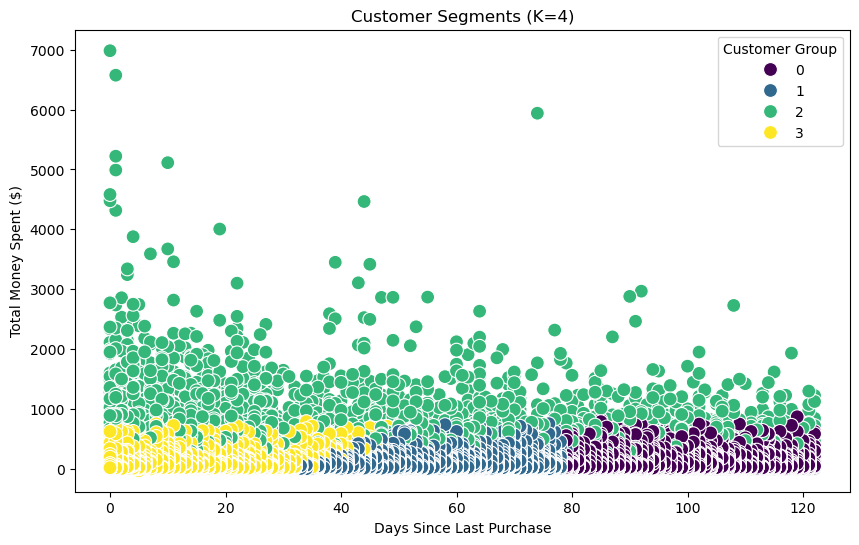

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Recency', y='Monetary', hue='cluster', palette='viridis', s=100)

plt.title('Customer Segments (K=4)')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Money Spent ($)')
plt.legend(title='Customer Group')
plt.show()

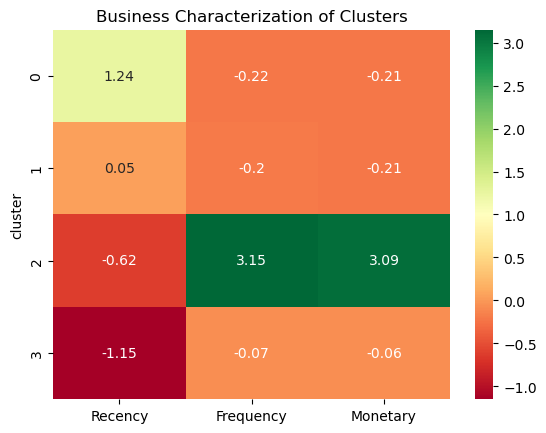

In [58]:
# Calculate mean values for each cluster
cluster_analysis = data_scaled.groupby('cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

# Display the heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cluster_analysis, annot=True, cmap='RdYlGn', fmt='g')
plt.title('Business Characterization of Clusters')
plt.show()

In [73]:
cluster_names = {
    0: 'Inactive',
    1: 'New / Active',
    2: 'VIP',
    3: 'Low Value'
}

data_scaled['cluster_name'] = data_scaled['cluster'].map(cluster_names)
data['cluster_name'] = data['cluster'].map(cluster_names)
data_scaled.head()

,Frequency,Monetary,Recency,cluster,cluster_name
0,-0.382834,-0.491490,0.314407,1,New / Active
1,-0.554694,-0.351872,0.847968,0,Inactive
2,0.329155,0.273274,-1.033535,3,Low Value
3,-0.431937,-0.470861,-0.387646,1,New / Active
4,-0.554694,-0.240907,-1.173946,3,Low Value


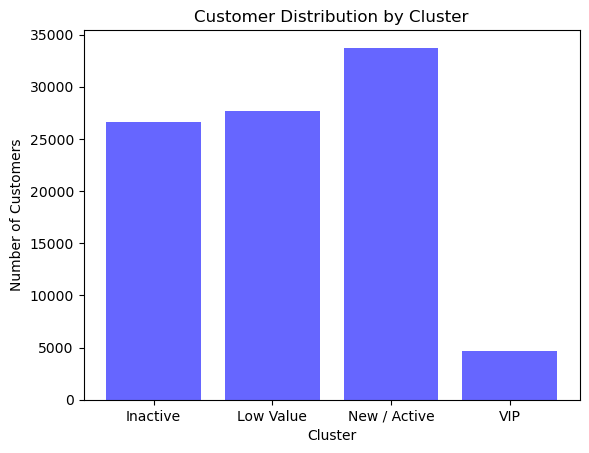

In [74]:
# 1. Get the counts
counts = data_scaled['cluster_name'].value_counts().sort_index()

# 2. Plot using the index as X and values as Height
plt.bar(counts.index, counts.values, color='blue', alpha=0.6)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(counts.index) # Ensures only 0, 1, 2, 3 show up on the axis
plt.title('Customer Distribution by Cluster')
plt.show()

In [79]:
#get mean from all values in each cluster
cluster_means = data.groupby('cluster_name').mean()
print(cluster_means)

                   user_id   Frequency    Monetary     Recency  cluster
cluster_name                                                           
Inactive      5.098144e+08   18.627588   92.471450  100.099812      0.0
Low Value     5.361015e+08   24.760436  121.557329   14.940705      3.0
New / Active  5.229683e+08   19.265437   92.823325   57.514363      1.0
VIP           4.862524e+08  155.912390  734.815340   33.676616      2.0


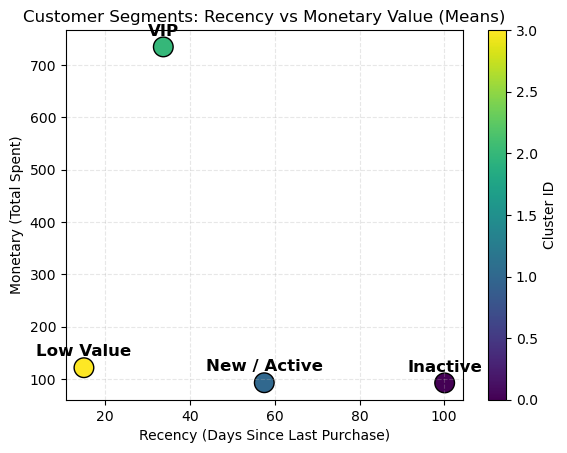

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate a dynamic offset for the text (3% of the total height)
# This ensures the text stays a bit above the point regardless of your data scale
offset = cluster_means['Monetary'].max() * 0.03

# 2. Plot the 4 mean points
plt.scatter(cluster_means['Recency'], cluster_means['Monetary'], 
            c=cluster_means['cluster'], s=200, cmap='viridis', edgecolors='black')

# 3. Add text labels for each point
for i, row in cluster_means.iterrows():
    plt.text(
        x=row['Recency'], 
        y=row['Monetary'] + offset, # Position text slightly above the point
        s=row.name, 
        fontsize=12, 
        fontweight='bold',
        ha='center' # Centers the text horizontally over the point
    )

# 4. Final Formatting
plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Monetary (Total Spent)')
plt.title('Customer Segments: Recency vs Monetary Value (Means)')
plt.colorbar(label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()